# Classical Reservoir Computing

In [1]:
# Import packages
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Level 1 data
ds_level1 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train"
)

# Convert to pandas DataFrame
df_level1 = ds_level1.to_pandas()

In [3]:
# -------------------------------------------------
# 1. Prepare Data
# -------------------------------------------------

df = df_level1.copy()

# Ensure correct date ordering
df["Date"] = pd.to_datetime(df["Date"], format='%d/%m/%Y')
df = df.sort_values("Date").reset_index(drop=True)

# Drop Date column
price_df = df.drop(columns=["Date"])

prices = price_df.values  # shape (T, 224)

# Log transform
log_prices = np.log(prices)

# -------------------------------------------------
# 2. Train / Validation Split (chronological)
# -------------------------------------------------

T = len(log_prices)

train_data = log_prices[:int(T * 0.75), :]
val_data = log_prices[int(T * 0.75):, :]

In [4]:
# -------------------------------------------------
# 3. Scale (fit only on training)
# -------------------------------------------------

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)

In [5]:
# -------------------------------------------------
# 4. PCA (fit only on training)
# -------------------------------------------------

K = 5
pca = PCA(n_components=K)

train_factors = pca.fit_transform(train_scaled)
val_factors = pca.transform(val_scaled)

In [6]:
WINDOW = 30
HORIZON = 6

def create_windows(data):
    X, Y = [], []
    for t in range(WINDOW, len(data) - HORIZON):
        X.append(data[t-WINDOW:t])
        Y.append(data[t:t+HORIZON].reshape(-1))
    return np.array(X), np.array(Y)

X_train, Y_train = create_windows(train_factors)
X_val, Y_val = create_windows(val_factors)

print(X_train.shape)  # (samples, 60, K)
print(Y_train.shape)  # (samples, 6*K)

(334, 30, 5)
(334, 30)


In [7]:
from numpy.linalg import inv

class ESN:
    def __init__(self, input_dim, reservoir_dim=150,
                 spectral_radius=0.9,
                 sparsity=0.1,
                 leak=0.3,
                 ridge=200):

        self.input_dim = input_dim
        self.reservoir_dim = reservoir_dim
        self.leak = leak
        self.ridge = ridge

        # Input weights
        self.Win = np.random.uniform(-1, 1, (reservoir_dim, input_dim))

        # Reservoir weights
        W = np.random.uniform(-1, 1, (reservoir_dim, reservoir_dim))
        mask = np.random.rand(*W.shape) < sparsity
        W *= mask

        # Scale spectral radius
        eigvals = np.linalg.eigvals(W)
        W *= spectral_radius / np.max(np.abs(eigvals))
        self.W = W

    def _run_reservoir(self, U):
        states = np.zeros((U.shape[0], self.reservoir_dim))

        for t in range(U.shape[0]):
            u = U[t]
            if t == 0:
                prev = np.zeros(self.reservoir_dim)
            else:
                prev = states[t-1]

            x = np.tanh(self.Win @ u + self.W @ prev)
            states[t] = (1 - self.leak)*prev + self.leak*x

        return states

    def fit(self, X, Y):

        # Collect final states for each window
        states = []

        for sample in X:
            reservoir_states = self._run_reservoir(sample)
            states.append(reservoir_states[-1])

        states = np.array(states)

        # Ridge regression
        I = np.eye(states.shape[1])
        self.Wout = inv(states.T @ states + self.ridge * I) @ states.T @ Y

    def predict(self, X):

        states = []

        for sample in X:
            reservoir_states = self._run_reservoir(sample)
            states.append(reservoir_states[-1])

        states = np.array(states)
        return states @ self.Wout

In [8]:
esn = ESN(
    input_dim=K,
    reservoir_dim=1000,
    spectral_radius=0.6,
    leak=0.3,
    ridge=10000
)

esn.fit(X_train, Y_train)

train_pred = esn.predict(X_train)
val_pred = esn.predict(X_val)

In [9]:
def reconstruct_from_esn(pred):
    pred = pred.reshape(-1, HORIZON, K)
    pred = pred.reshape(-1, K)

    log_scaled = pca.inverse_transform(pred)
    log_prices = scaler.inverse_transform(log_scaled)

    prices = np.exp(log_prices)
    return prices.reshape(-1, HORIZON, 224)

In [10]:
def compute_overall_metrics_esn(pred, true, eps=1e-8):

    pred_prices = reconstruct_from_esn(pred)
    true_prices = reconstruct_from_esn(true)

    mse = np.mean((pred_prices - true_prices)**2)
    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs((pred_prices - true_prices) /
               (true_prices + eps))
    ) * 100

    return rmse, mape


train_rmse, train_mape = compute_overall_metrics_esn(train_pred, Y_train)
val_rmse, val_mape = compute_overall_metrics_esn(val_pred, Y_val)

print("Train RMSE:", train_rmse)
print("Train MAPE:", train_mape)

print("Validation RMSE:", val_rmse)
print("Validation MAPE:", val_mape)

Train RMSE: 0.010120908791897738
Train MAPE: 3.6076275125926323
Validation RMSE: 0.009137139745018964
Validation MAPE: 3.7522682508923126


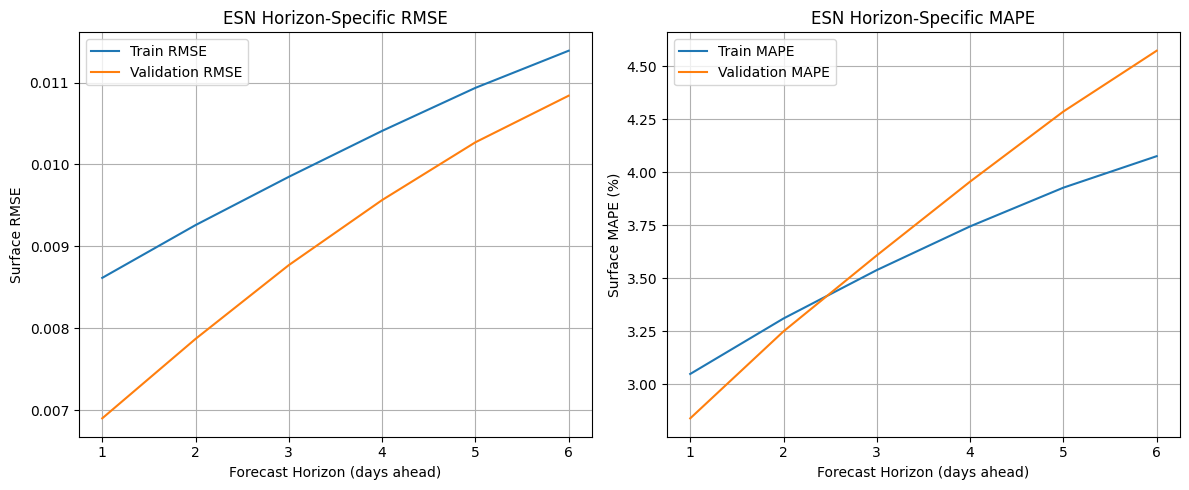

In [11]:
def compute_horizon_metrics_esn(pred, true, eps=1e-8):

    pred_prices = reconstruct_from_esn(pred)
    true_prices = reconstruct_from_esn(true)

    n_samples = pred_prices.shape[0]
    H = pred_prices.shape[1]

    rmse_h = []
    mape_h = []

    for h in range(H):

        pred_h = pred_prices[:, h, :]
        true_h = true_prices[:, h, :]

        mse = np.mean((pred_h - true_h)**2)
        rmse = np.sqrt(mse)

        mape = np.mean(
            np.abs((pred_h - true_h) /
                   (true_h + eps))
        ) * 100

        rmse_h.append(rmse)
        mape_h.append(mape)

    return np.array(rmse_h), np.array(mape_h)


train_rmse_h, train_mape_h = compute_horizon_metrics_esn(train_pred, Y_train)
val_rmse_h, val_mape_h = compute_horizon_metrics_esn(val_pred, Y_val)

import matplotlib.pyplot as plt
import numpy as np

horizon = np.arange(1, len(train_rmse_h) + 1)

plt.figure(figsize=(12,5))

# RMSE
plt.subplot(1,2,1)
plt.plot(horizon, train_rmse_h, label="Train RMSE")
plt.plot(horizon, val_rmse_h, label="Validation RMSE")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("Surface RMSE")
plt.title("ESN Horizon-Specific RMSE")
plt.legend()
plt.grid(True)

# MAPE
plt.subplot(1,2,2)
plt.plot(horizon, train_mape_h, label="Train MAPE")
plt.plot(horizon, val_mape_h, label="Validation MAPE")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("Surface MAPE (%)")
plt.title("ESN Horizon-Specific MAPE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()